# M8 - Equipment Health and SEMI E10 Monitoring

**Goal.** Add an equipment-health layer on top of the M2-M7 fab simulator:
a per-tool SEMI E10 state timeline, the RAM metrics (MTBF, MTTR,
availability, utilization) that timeline supports, a maintenance-timing
decision (when to schedule preventive maintenance, PM), an alert-priority
score that ranks degradation alerts by bottleneck impact, and a simulated
multivariate sensor layer with a gradient-boosting (GB) health model scored
against known synthetic ground truth.

**Structure.**
1. E10 tool-state layer: build a per-tool state timeline on a run with one
   scheduled PM and one unscheduled breakdown injected.
2. RAM metrics: MTBF, MTTR, availability, utilization per tool and station.
3. Maintenance timing: a CRN-paired comparison of PM timings (immediate,
   mid, late) against a no-degradation baseline, costed with the M6 cost
   model plus PM downtime and scrap cost.
4. Alert priority: a transparent severity x bottleneck-criticality x
   cost-exposure score, demonstrated on LITHO (bottleneck) vs METRO
   (non-bottleneck) and checked against realized CRN-paired cost impact.
5. Sensor simulation and health model: a simulated multivariate tool-sensor
   layer (two channels wired to a degradation ramp, three pure-noise
   distractors), a GB classifier trained with an episode-level split, and a
   GB-vs-EWMA detection-quality comparison with SHAP global importance.

**Honest scope.** The SEMI E10 state mapping here is STYLIZED, not a
standards-compliant E10 implementation: only the states this project's DES
can actually observe are populated (`PRODUCTIVE`, `STANDBY`,
`SCHEDULED DOWNTIME`, `UNSCHEDULED DOWNTIME`); `ENGINEERING` is declared in
the schema for completeness but never populated, a documented limitation,
not a bug. All costs (PM downtime rate, scrap cost per defective wafer,
processing/holding rates) are illustrative constants chosen by the project
owner for internal ranking, not real fab prices; every dollar figure below
should be read as a ranking under stated assumptions, never as a forecast.
The sensor channels in Section 6 are entirely self-generated by this
project with a documented rule wiring exactly two channels to a
degradation ramp (CLAUDE.md owner-approved exception for gradient boosting
plus SHAP, framed as measuring detection quality against known synthetic
ground truth). Any model trained on these channels can only ever
rediscover the rule this project itself wrote; nothing here demonstrates
predictive maintenance capability on a real fab. All generation uses fixed
seeds; runtime is kept under about 15 minutes by reusing the small
`n_reps`/episode counts already validated by the M8 check scripts.


In [1]:
%matplotlib inline
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

NB_START = time.time()

ROOT = Path("..")
for p in ["src", "src/generator", "src/quality", "src/decision", "src/kpi",
          "src/monitoring", "src/equipment"]:
    sys.path.insert(0, str(ROOT / p))

from factory_generator import (
    default_config, draw_randoms, simulate,
    ScheduledDowntimeAnomaly, BreakdownAnomaly,
)
from cost_model import CostRates, cost_components
from e10_states import build_tool_state_timeline, E10_STATES
from ram_metrics import state_time_decomposition, ram_metrics_by_tool, ram_metrics_by_station
from maintenance_whatif import (
    compare_pm_timings, summarize_pm_comparison, demo_litho_pm_timing,
    build_pm_scenario, DEFAULT_PM_TIMES,
)
from alert_priority import compare_bottleneck_vs_nonbottleneck, compute_priority
from sensor_sim import make_episodes, DEGRADATION_WIRING, CHANNELS
from pdm_model import (
    split_episodes, train_health_model, score_test_episodes, held_out_auc,
    shap_importance, evaluate_health_scores, evaluate_ewma_baseline,
    comparison_table,
)

FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

cfg = default_config()
print(f"route: {cfg.route}")
n_tools_by_station = {s: v.n_tools for s, v in cfg.stations.items()}
print(f"stations (n_tools): {n_tools_by_station}")


route: ['CLEAN', 'FURNACE', 'DEPO', 'LITHO', 'ETCH', 'LITHO', 'IMPLANT', 'METRO']
stations (n_tools): {'CLEAN': 2, 'FURNACE': 2, 'DEPO': 2, 'LITHO': 2, 'ETCH': 2, 'IMPLANT': 2, 'METRO': 2}


## Step 1 - SEMI E10 tool-state layer

SEMI E10 ("Standard for Definition and Measurement of Equipment
Reliability, Availability, and Maintainability") is the semiconductor
industry's naming convention for equipment states. `src/equipment/e10_states.py`
builds a STYLIZED per-tool timeline onto that naming: `PRODUCTIVE` comes
directly from the event log's process intervals for that `tool_id`;
`SCHEDULED DOWNTIME` and `UNSCHEDULED DOWNTIME` come from injected
maintenance/breakdown anomalies attributed to a specific tool (the
highest-index tool at a station, matching the tool-pool acquisition rule);
`STANDBY` is the residual bucket (up, not running); `ENGINEERING` is
declared but never populated (this DES has no concept of an engineering
run distinct from a production run).

To exercise every state at least once, this run injects one scheduled PM
at FURNACE and one unscheduled breakdown at LITHO on top of the default
seed-42 baseline.


In [2]:
draws = draw_randoms(cfg, seed=42)
injected_scenario = [
    ScheduledDowntimeAnomaly(station="FURNACE", t_start=10 * 24.0,
                             t_end=10 * 24.0 + 8.0, tools_removed=1),
    BreakdownAnomaly(station="LITHO", t_start=20 * 24.0,
                     t_end=20 * 24.0 + 12.0, tools_removed=1),
]
log, life, meta = simulate(cfg, draws, anomalies=injected_scenario)
timeline = build_tool_state_timeline(log, meta)

print(f"lots simulated: {log['lot_id'].nunique()}, event rows: {len(log)}")
print(f"tools in timeline: {timeline['tool_id'].nunique()}")
print(f"E10 states declared: {E10_STATES}")
print(f"E10 states observed on this run: {sorted(timeline['e10_state'].unique())}")


lots simulated: 1429, event rows: 11432
tools in timeline: 14
E10 states declared: ('PRODUCTIVE', 'STANDBY', 'SCHEDULED DOWNTIME', 'UNSCHEDULED DOWNTIME', 'ENGINEERING')
E10 states observed on this run: ['PRODUCTIVE', 'SCHEDULED DOWNTIME', 'STANDBY', 'UNSCHEDULED DOWNTIME']


**State-decomposition figure.** Stacked bar of hours per E10 state for
every tool, ordered by station. FURNACE-2 carries the injected scheduled
PM, LITHO-2 carries the injected breakdown; every other tool shows only
`PRODUCTIVE`/`STANDBY` on this run.


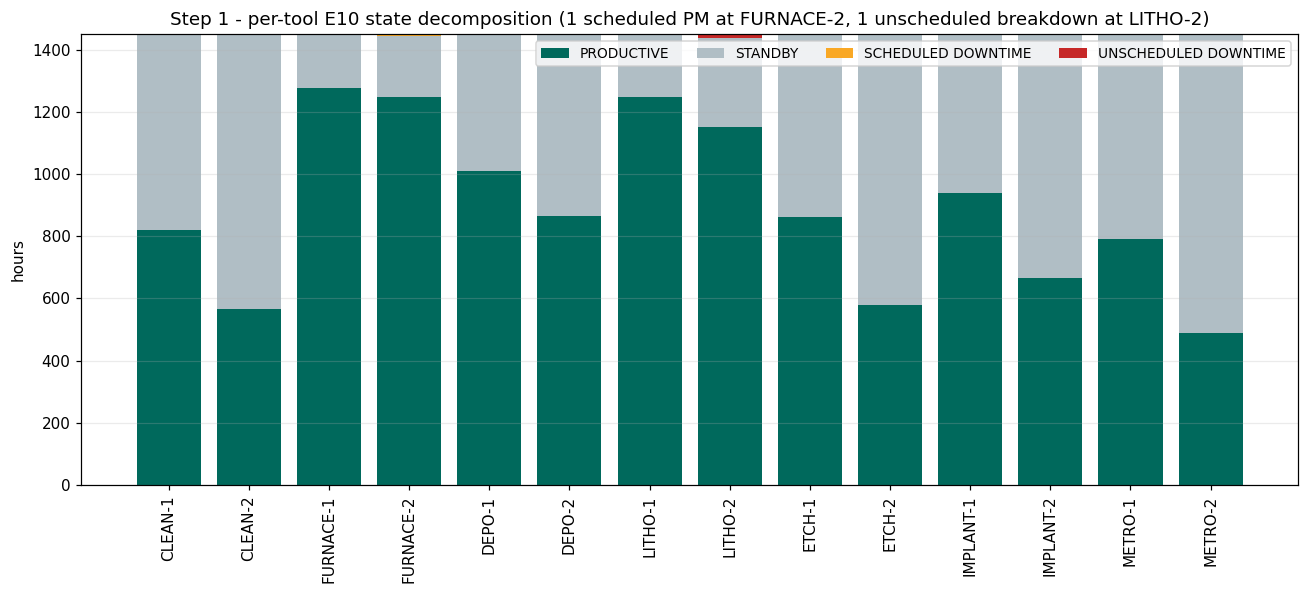

In [3]:
decomp = state_time_decomposition(timeline, ["tool_id"])
pivot = decomp.pivot(index="tool_id", columns="e10_state", values="hours").fillna(0.0)
# stable station order matching cfg.stations, tool index within station
station_order = list(cfg.stations.keys())
tool_order = [t for st in station_order for t in sorted(
    [tid for tid in pivot.index if tid.startswith(st + "-")],
    key=lambda x: int(x.split("-")[-1]))]
pivot = pivot.reindex(tool_order)

state_colors = {
    "PRODUCTIVE": "#00695C",
    "STANDBY": "#B0BEC5",
    "SCHEDULED DOWNTIME": "#F9A825",
    "UNSCHEDULED DOWNTIME": "#C62828",
    "ENGINEERING": "#6A1B9A",
}
present_states = [s for s in E10_STATES if s in pivot.columns]

fig, ax = plt.subplots(figsize=(12, 5.5))
bottom = np.zeros(len(pivot))
for state in present_states:
    vals = pivot[state].to_numpy()
    ax.bar(pivot.index, vals, bottom=bottom, color=state_colors[state], label=state)
    bottom += vals
ax.set_ylabel("hours")
ax.set_title("Step 1 - per-tool E10 state decomposition "
             "(1 scheduled PM at FURNACE-2, 1 unscheduled breakdown at LITHO-2)")
ax.tick_params(axis="x", rotation=90)
ax.legend(fontsize=9, ncol=len(present_states))
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG / "m8_e10_state_decomposition.png", bbox_inches="tight", dpi=150)
plt.show()


**State-share table.** Same decomposition as a share of each tool's
total time, restricted to the two tools carrying an injected event plus
one clean tool from each of those stations for contrast.


In [4]:
share_pivot = decomp.pivot(index="tool_id", columns="e10_state", values="share").fillna(0.0)
share_pivot = share_pivot.reindex(tool_order)
highlight_tools = ["FURNACE-1", "FURNACE-2", "LITHO-1", "LITHO-2"]
share_table = share_pivot.loc[highlight_tools, present_states].round(4)
share_table


e10_state,PRODUCTIVE,STANDBY,SCHEDULED DOWNTIME,UNSCHEDULED DOWNTIME
tool_id,,,,
FURNACE-1,0.8797,0.1203,0.0000,0.0000
FURNACE-2,0.8615,0.1337,0.0048,0.0000
LITHO-1,0.8606,0.1394,0.0000,0.0000
LITHO-2,0.7935,0.1988,0.0000,0.0076


## Step 2 - RAM metrics (MTBF, MTTR, availability, utilization)

`src/equipment/ram_metrics.py` computes Reliability/Availability/
Maintainability metrics from the E10 timeline: only `UNSCHEDULED DOWNTIME`
counts as a "failure" for MTBF/MTTR (SEMI E10 draws finer distinctions this
project's DES does not model). Availability is up time (`PRODUCTIVE` +
`STANDBY`) over total time; utilization is `PRODUCTIVE` time over total
time, a different quantity from the generator's own design-time slot
utilization used elsewhere in this project for capacity planning. A tool
with zero unscheduled-downtime events has an undefined MTBF/MTTR by these
formulas, reported as `NaN` rather than a misleading 0 or infinity.


In [5]:
ram_tool = ram_metrics_by_tool(timeline)
display_cols = ["tool_id", "station", "hours_total", "n_unscheduled_events",
                "mtbf_hours", "mttr_hours", "availability", "utilization"]
ram_tool[display_cols].round(4)


,tool_id,station,hours_total,n_unscheduled_events,mtbf_hours,mttr_hours,availability,utilization
0,CLEAN-1,CLEAN,1450.7169,0,NaN,NaN,1.0000,0.5660
1,CLEAN-2,CLEAN,1450.7169,0,NaN,NaN,1.0000,0.3901
2,DEPO-1,DEPO,1450.7169,0,NaN,NaN,1.0000,0.6974
3,DEPO-2,DEPO,1450.7169,0,NaN,NaN,1.0000,0.5960
4,ETCH-1,ETCH,1450.7169,0,NaN,NaN,1.0000,0.5942
5,ETCH-2,ETCH,1450.7169,0,NaN,NaN,1.0000,0.3998
6,FURNACE-1,FURNACE,1450.7169,0,NaN,NaN,1.0000,0.8797
7,FURNACE-2,FURNACE,1450.7169,0,NaN,NaN,0.9952,0.8615
8,IMPLANT-1,IMPLANT,1450.7169,0,NaN,NaN,1.0000,0.6466
9,IMPLANT-2,IMPLANT,1450.7169,0,NaN,NaN,1.0000,0.4598


In [6]:
ram_station = ram_metrics_by_station(timeline)
display_cols_s = ["station", "n_tools", "n_unscheduled_events",
                  "mtbf_hours", "mttr_hours", "availability", "utilization"]
ram_station[display_cols_s].round(4)


,station,n_tools,n_unscheduled_events,mtbf_hours,mttr_hours,availability,utilization
0,CLEAN,2,0,NaN,NaN,1.0000,0.4780
1,DEPO,2,0,NaN,NaN,1.0000,0.6467
2,ETCH,2,0,NaN,NaN,1.0000,0.4970
3,FURNACE,2,0,NaN,NaN,0.9976,0.8706
4,IMPLANT,2,0,NaN,NaN,1.0000,0.5532
5,LITHO,2,1,961.8492,11.0754,0.9962,0.8271
6,METRO,2,0,NaN,NaN,1.0000,0.4407


**Reading.** LITHO-2 is the only tool with a logged unscheduled-downtime
event on this run, so it is the only row with a finite MTBF/MTTR; every
other tool shows `NaN` by construction (no failures to measure between).
FURNACE-2 shows availability just under 1.0 because of the injected
scheduled PM, while its utilization stays close to FURNACE-1's since
`PRODUCTIVE-wins` truncation means the PM window never displaces logged
production. At the station level, LITHO keeps the highest utilization of
the seven stations, consistent with its role as the engineered bottleneck.


## Step 3 - Maintenance-timing what-if: when to schedule PM

`src/equipment/maintenance_whatif.py` turns the E10 layer into a decision:
given a bottleneck tool (LITHO) degrading at a fixed rate from a fixed
onset, when should the operator schedule its PM? Acting early limits
accumulated congestion and yield damage but the PM's own downtime lands
sooner; acting late defers the downtime but lets the degradation and its
knock-on costs accumulate longer. Every replication draws ONE random table
(`draw_randoms(cfg, seed0 + rep)`) and runs it through `baseline` (no
degradation, no PM) plus each PM-timing scenario, so any difference between
scenarios comes only from the anomaly list, never from re-sampled
randomness (the same CRN discipline used throughout M4/M6/M7).

**Pairing discipline check.** A baseline-vs-baseline comparison under this
scheme must show EXACTLY zero delta on cycle time, violation rate, and
yield; this is the same exact-zero gate used in M7's yield what-if, one
layer up.


In [7]:
baseline_pair_1 = compare_pm_timings(cfg=cfg, n_reps=5, seed0=6000)
baseline_pair_2 = compare_pm_timings(cfg=cfg, n_reps=5, seed0=6000)
b1 = baseline_pair_1[baseline_pair_1["scenario"] == "baseline"].reset_index(drop=True)
b2 = baseline_pair_2[baseline_pair_2["scenario"] == "baseline"].reset_index(drop=True)
max_abs_deltas = pd.Series({
    "d_mean_cycle_time": (b1["mean_cycle_time"] - b2["mean_cycle_time"]).abs().max(),
    "d_violation_rate": (b1["violation_rate"] - b2["violation_rate"]).abs().max(),
    "d_mean_lot_yield": (b1["mean_lot_yield"] - b2["mean_lot_yield"]).abs().max(),
})
print("baseline-vs-baseline max |delta| (must all be exactly 0.0):")
print(max_abs_deltas)
assert (max_abs_deltas == 0.0).all(), "CRN pairing check failed: nonzero delta on baseline-vs-baseline"
print("pairing discipline verified: exact zero on every metric")


baseline-vs-baseline max |delta| (must all be exactly 0.0):
d_mean_cycle_time    0.0
d_violation_rate     0.0
d_mean_lot_yield     0.0
dtype: float64
pairing discipline verified: exact zero on every metric


### Reference demonstration: LITHO degradation, three PM timings

Degradation onset is fixed at day 20 (`alpha = 0.01` per hour of exposure);
the three candidate PM times are `immediate_pm` (1 day after onset),
`mid_pm` (10 days of accumulated exposure), and `late_pm` (25 days), each
followed by a fixed 24-hour repair window. `n_reps = 15` keeps this well
under a minute while still giving a stable directional read (the injected
LITHO effect is large relative to run-to-run queueing noise at this
station's utilization).


In [8]:
t_maint_start = time.time()
paired_litho_pm = compare_pm_timings(station="LITHO", cfg=cfg, n_reps=15, seed0=6000)
pm_summary = summarize_pm_comparison(paired_litho_pm)
t_maint_elapsed = time.time() - t_maint_start
print(f"PM-timing comparison wall time: {t_maint_elapsed:.1f}s")
display_cols_pm = ["scenario", "mean_cycle_time", "violation_rate",
                  "mean_lot_yield", "congestion_cost", "scrap_cost",
                  "pm_downtime_cost", "total_cost"]
pm_summary[display_cols_pm].round(4)


PM-timing comparison wall time: 5.6s


,scenario,mean_cycle_time,violation_rate,mean_lot_yield,congestion_cost,scrap_cost,pm_downtime_cost,total_cost
0,baseline,14.7760,0.1016,0.9520,1.356312e+06,259190.0,0.0,1.615502e+06
1,immediate_pm,15.9961,0.1050,0.9515,1.372737e+06,261650.0,120000.0,1.754387e+06
2,mid_pm,67.0959,0.1337,0.9471,2.049328e+06,285350.0,120000.0,2.454678e+06
3,late_pm,226.7809,0.2400,0.9314,4.097397e+06,369970.0,120000.0,4.587367e+06


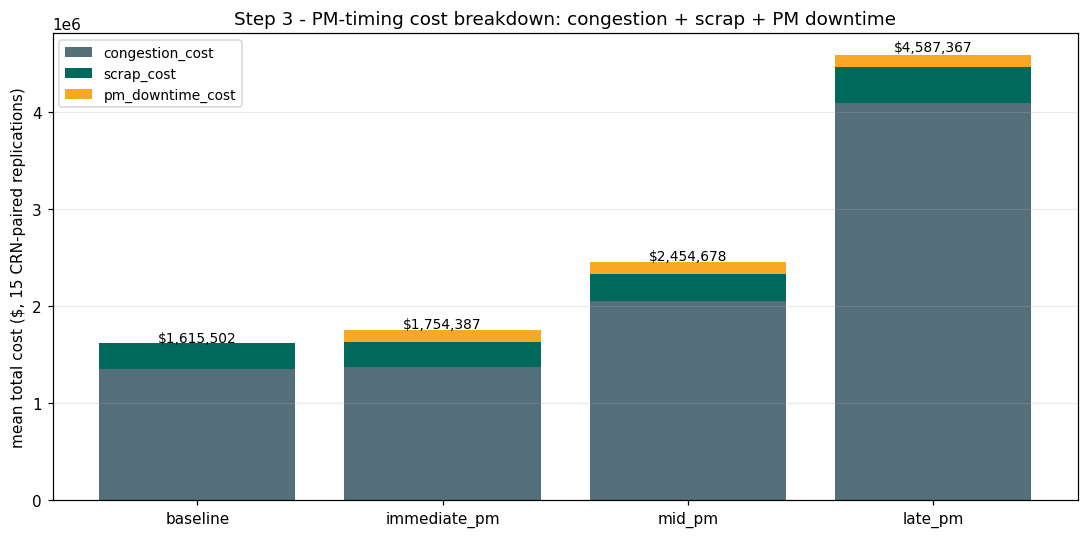

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_pm = {"baseline": "#546E7A", "immediate_pm": "#1565C0",
            "mid_pm": "#EF6C00", "late_pm": "#C62828"}
cost_cols = ["congestion_cost", "scrap_cost", "pm_downtime_cost"]
cost_colors = ["#546E7A", "#00695C", "#F9A825"]
bottom = np.zeros(len(pm_summary))
for col, c in zip(cost_cols, cost_colors):
    vals = pm_summary[col].to_numpy()
    ax.bar(pm_summary["scenario"], vals, bottom=bottom, color=c, label=col)
    bottom += vals
for i, total in enumerate(pm_summary["total_cost"]):
    ax.text(i, total * 1.01, f"${total:,.0f}", ha="center", fontsize=9)
ax.set_ylabel("mean total cost ($, 15 CRN-paired replications)")
ax.set_title("Step 3 - PM-timing cost breakdown: congestion + scrap + PM downtime")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG / "m8_pm_timing_cost.png", bbox_inches="tight", dpi=150)
plt.show()


**Reading.** The `baseline` (no degradation, no PM at all) is the
cheapest reference. Among the three PM timings, `immediate_pm` costs the
least: acting right after onset limits how long the tool runs slower and
keeps the congestion and scrap cost small, even though its PM downtime
lands early. `mid_pm` costs noticeably more and `late_pm` costs the most
by a wide margin: the longer LITHO (the bottleneck) is left degrading, the
more congestion cost and yield loss accumulate, and that accumulated cost
dominates the fixed PM downtime cost that is identical across all three
timings. The trade-off the module is built to show is real (immediate PM
does still pay its own downtime cost up front) but in this reference
demonstration, at this severity and onset, acting early dominates on total
cost.


## Step 4 - Alert-priority scoring: LITHO vs METRO

`src/equipment/alert_priority.py` turns a degradation alert into one
number: `priority = severity * bottleneck_criticality * cost_exposure_per_hour`.
Severity is the fractional process-time inflation after a fixed 24-hour
exposure (`alpha * 24`); bottleneck criticality is the station's empirical
slot utilization on a clean baseline run (Theory-of-Constraints logic
already used elsewhere in this project); cost exposure per hour is the M6
cost model's processing rate scaled by the station's tool count. No factor
is weighted or tuned; the formula is the plain product, chosen because any
one factor near zero should drive priority near zero, unlike a weighted
sum.

**Demonstration.** The identical severity (`alpha = 0.01`) is applied to
LITHO (the engineered bottleneck, slot utilization about 0.85) and to
METRO (a slack station, about 0.44). Both stations share the same tool
count and processing rate, so `cost_exposure_per_hour` is identical between
them; only `bottleneck_criticality` differs, and it is what drives the
ranking.


In [10]:
rates = CostRates()
p_litho, p_metro = compare_bottleneck_vs_nonbottleneck(
    alpha=0.01, bottleneck_station="LITHO", nonbottleneck_station="METRO",
    cfg=cfg, rates=rates)

priority_table = pd.DataFrame([
    {"station": "LITHO", "severity": p_litho.severity,
     "bottleneck_criticality": p_litho.bottleneck_criticality,
     "cost_exposure_per_hour": p_litho.cost_exposure_per_hour,
     "priority_score": p_litho.priority},
    {"station": "METRO", "severity": p_metro.severity,
     "bottleneck_criticality": p_metro.bottleneck_criticality,
     "cost_exposure_per_hour": p_metro.cost_exposure_per_hour,
     "priority_score": p_metro.priority},
])
priority_table.round(4)


,station,severity,bottleneck_criticality,cost_exposure_per_hour,priority_score
0,LITHO,0.24,0.8256,200.0,39.6307
1,METRO,0.24,0.4444,200.0,21.3317


**The score's ranking is validated against simulated reality, not
asserted.** The priority score alone would mean nothing if it did not
track what actually happens in the simulator. To check that, the same
same-severity LITHO-vs-METRO degradation is run as a realized, CRN-paired
cost-impact comparison: 15 replications, each sharing one random draw table
between a no-degradation baseline and a late-PM (day 45) degraded run, at
the same `alpha = 0.01` and the same onset used for the score above.


In [11]:
t_alert_start = time.time()
n_reps_impact = 15
seed0_impact = 7000
t_onset_impact = 20 * 24.0
pm_time_impact = 45 * 24.0
pm_duration_impact = 24.0
t0_w, t1_w = cfg.warmup_hours, cfg.horizon_hours

def realized_cost_impact(station: str) -> float:
    deltas = []
    for rep in range(n_reps_impact):
        draws_r = draw_randoms(cfg, seed0_impact + rep)
        log_b, _, _ = simulate(cfg, draws_r)
        anomalies = build_pm_scenario(station, t_onset_impact, 0.01,
                                      pm_time_impact, pm_duration_impact)
        log_s, _, _ = simulate(cfg, draws_r, anomalies=anomalies)
        cost_b = cost_components(log_b, t0_w, t1_w, rates)["total"]
        cost_s = cost_components(log_s, t0_w, t1_w, rates)["total"]
        deltas.append(cost_s - cost_b)
    return float(sum(deltas) / len(deltas))

impact_litho = realized_cost_impact("LITHO")
impact_metro = realized_cost_impact("METRO")
t_alert_elapsed = time.time() - t_alert_start
print(f"realized cost-impact comparison wall time: {t_alert_elapsed:.1f}s")

impact_table = priority_table[["station", "priority_score"]].copy()
impact_table["realized_mean_cost_impact"] = [impact_litho, impact_metro]
impact_table.round(2)


realized cost-impact comparison wall time: 4.2s


,station,priority_score,realized_mean_cost_impact
0,LITHO,39.63,2700394.74
1,METRO,21.33,781332.97


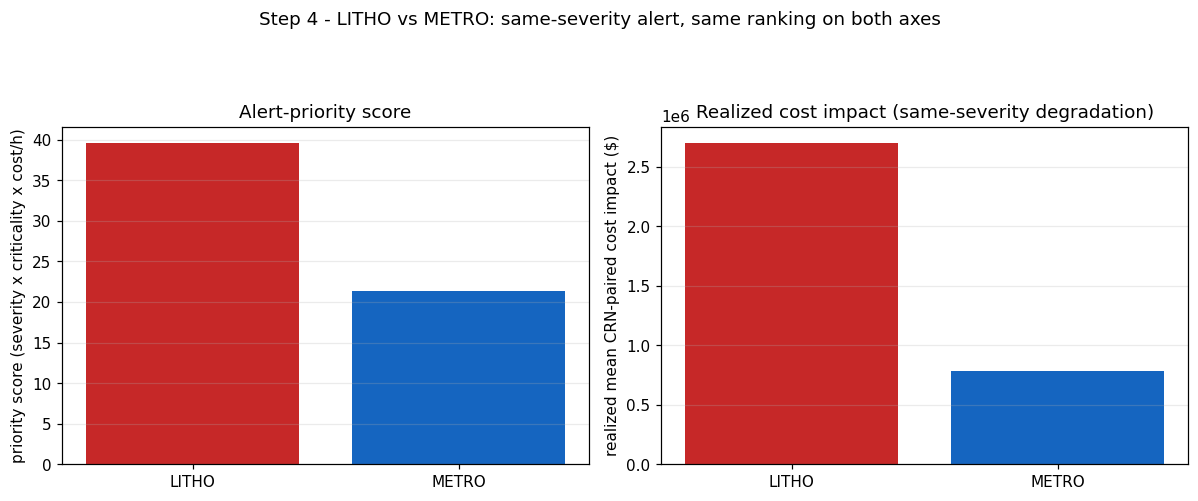

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
stations_plot = ["LITHO", "METRO"]
colors_bar = ["#C62828", "#1565C0"]

axes[0].bar(stations_plot, impact_table["priority_score"], color=colors_bar)
axes[0].set_ylabel("priority score (severity x criticality x cost/h)")
axes[0].set_title("Alert-priority score")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(stations_plot, impact_table["realized_mean_cost_impact"], color=colors_bar)
axes[1].set_ylabel("realized mean CRN-paired cost impact ($)")
axes[1].set_title("Realized cost impact (same-severity degradation)")
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("Step 4 - LITHO vs METRO: same-severity alert, same ranking on both axes")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIG / "m8_alert_priority_validation.png", bbox_inches="tight", dpi=150)
plt.show()


**Reading.** LITHO's priority score is roughly 1.9x METRO's, driven
entirely by bottleneck criticality since severity and cost exposure per
hour are shared inputs. The realized cost impact tells the same story at a
much larger ratio: the same-severity degradation costs several times more
at LITHO than at METRO, because congestion at an already-saturated
bottleneck compounds in a way that congestion at a slack station does not.
The score's ranking is validated by simulated reality here, not asserted:
the formula did not have to produce a ranking that agrees with the
realized cost impact, and it does.


## Step 5 - Sensor simulation and health model

`src/equipment/sensor_sim.py` generates a simulated multivariate
tool-sensor signature: one row per (tool, day), five channels
(`temperature`, `vibration`, `pressure`, `flow`, `current`) modeled as a
stationary AR(1) noise process. For LITHO, exactly two channels are wired
to a degradation ramp with different gain and timing: `vibration` reacts
fastest and strongest with no lag, `temperature` reacts more slowly with a
3-day lag (heat buildup takes time to show at the sensor). The other three
channels are pure-noise distractors with no degradation term at all, so
the health model and SHAP have something to correctly ignore, not only
channels to correctly use. Every channel here is entirely self-generated
by this project (see the honest-scope note above); the point of this
section is measuring whether a model recovers the rule this project wrote,
never a claim of real predictive maintenance capability.

Each "episode" is one independent simulated run (its own seed, randomly
drawn onset day and severity) on one designated degrading tool, with every
other tool of the same episode running clean for contrast.


In [13]:
N_EPISODES = 24
N_TRAIN = 16
HORIZON_DAYS = 90
DURATION_DAYS = 20
BASE_SEED = 9000

t_sensor_start = time.time()
episodes = make_episodes(N_EPISODES, station="LITHO", n_tools=2,
                         horizon_days=HORIZON_DAYS, duration_days=DURATION_DAYS,
                         base_seed=BASE_SEED)
train_eps, test_eps = split_episodes(episodes, n_train=N_TRAIN)
print(f"episodes: {N_EPISODES} total ({N_TRAIN} train, {N_EPISODES - N_TRAIN} test), "
      f"{HORIZON_DAYS}-day horizon, wired station LITHO")
print(f"DEGRADATION_WIRING['LITHO']: {DEGRADATION_WIRING['LITHO']}")


episodes: 24 total (16 train, 8 test), 90-day horizon, wired station LITHO
DEGRADATION_WIRING['LITHO']: {'vibration': {'gain': 0.35, 'lag_days': 0}, 'temperature': {'gain': 6.0, 'lag_days': 3}}


**One degraded episode, all five channels.** The degrading tool's
onset day and severity vary by episode; this figure shows one representative
test episode so the wired-vs-distractor contrast is visible by eye.


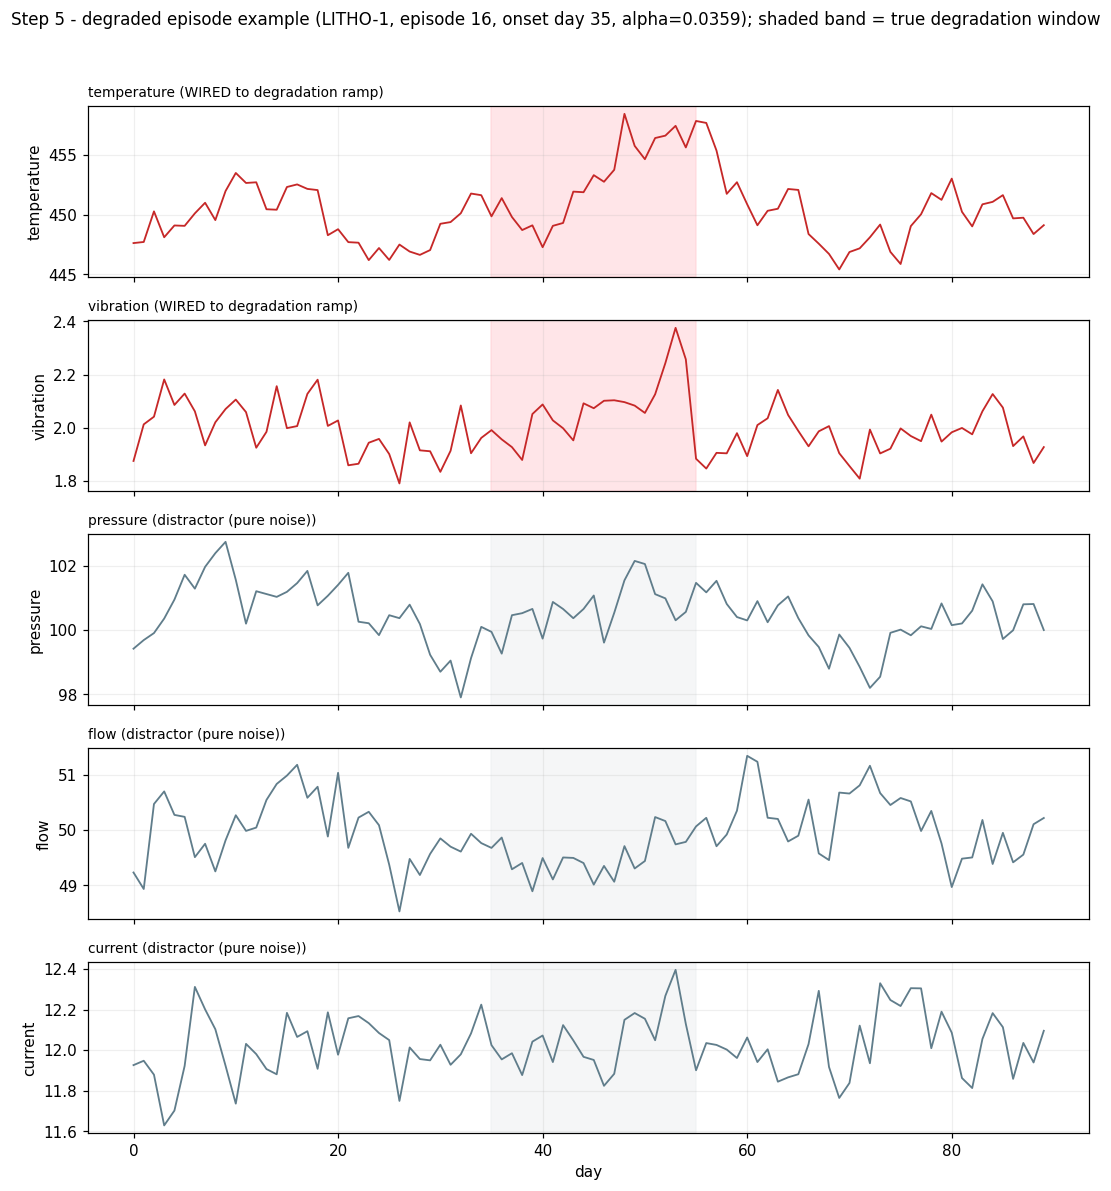

In [14]:
demo_ep = test_eps[0]
demo_cfg = demo_ep["config"]
demo_frame = demo_ep["frame"]
demo_tool = f"LITHO-{demo_cfg.degrading_tool_index + 1}"
demo_tool_df = demo_frame[demo_frame["tool_id"] == demo_tool].sort_values("day")

fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(10, 11), sharex=True)
wired = set(DEGRADATION_WIRING["LITHO"].keys())
for ax, ch in zip(axes, CHANNELS):
    color = "#C62828" if ch in wired else "#607D8B"
    ax.plot(demo_tool_df["day"], demo_tool_df[ch], color=color, lw=1.2)
    ax.axvspan(demo_cfg.onset_day, demo_cfg.onset_day + demo_cfg.duration_days,
              color="#FFCDD2" if ch in wired else "#ECEFF1", alpha=0.5)
    tag = "WIRED to degradation ramp" if ch in wired else "distractor (pure noise)"
    ax.set_ylabel(ch)
    ax.set_title(f"{ch} ({tag})", fontsize=9, loc="left")
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("day")
fig.suptitle(f"Step 5 - degraded episode example ({demo_tool}, episode "
            f"{demo_cfg.episode_id}, onset day {demo_cfg.onset_day}, "
            f"alpha={demo_cfg.alpha:.4f}); shaded band = true degradation window",
            fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(FIG / "m8_sensor_episode.png", bbox_inches="tight", dpi=150)
plt.show()


**Reading.** `vibration` and `temperature` visibly drift upward once
the shaded degradation window opens, `temperature` lagging `vibration` by
a few days as designed; `pressure`, `flow`, and `current` show only their
stationary AR(1) noise with no relationship to the shaded window, exactly
the distractor role they are built to play.

### GB training with episode-level split

Rolling-window features (7-day trailing mean/std/slope per channel) make
consecutive days of the same tool-episode highly correlated, so splitting
by whole EPISODES (not individual days) into train and test keeps every
test episode's onset day, severity, and noise realization unseen during
training. A `GradientBoostingClassifier` (fixed `random_state`) is fit on
the training episodes' features to predict the `degraded` ground-truth
label per tool-day.


In [15]:
model, train_table = train_health_model(train_eps)
scored = score_test_episodes(model, test_eps)
auc = held_out_auc(scored)
print(f"held-out ROC AUC (vs known synthetic ground truth): {auc:.4f}")
print("(this measures recovery of a self-generated rule, not real-fab predictive power)")


held-out ROC AUC (vs known synthetic ground truth): 0.7871
(this measures recovery of a self-generated rule, not real-fab predictive power)


### GB vs EWMA: detection delay, false-alarm rate, precision

Both rows below are scored with the same `monitoring.evaluation` vocabulary
used for the M5 EWMA/control-chart detectors, on the SAME held-out
episodes, so the columns are directly comparable. The EWMA baseline runs
on the single strongest wired channel only (`vibration`, per the SHAP
ranking below); the GB health score uses all five channels.

**Honest framing.** The classic single-channel EWMA detects slightly
FASTER than gradient boosting on all channels, while GB cuts the
false-alarm rate about 3.7x and lifts precision correspondingly. Classic
control-chart methods stay competitive on raw detection speed; the
gradient-boosting model earns its keep specifically on multivariate
precision (fewer false alarms per true alert), not by being superior
across every metric.


In [16]:
shap_table = shap_importance(model, train_table)
strongest_channel = shap_table.iloc[0]["channel"]

gb_agg = evaluate_health_scores(scored, test_eps)
ewma_agg = evaluate_ewma_baseline(test_eps, channel=strongest_channel)
gb_vs_ewma = comparison_table(gb_agg, ewma_agg, strongest_channel)
gb_vs_ewma.round(4)


,method,mean_detection_delay_days,false_alarm_rate,precision,recall
0,gradient_boosting (all channels),11.2857,0.0163,0.9423,0.875
1,ewma (vibration only),9.8571,0.0598,0.8830,0.875


**SHAP global importance.** Ranks the five raw sensor channels by
summed mean absolute SHAP value of their three engineered features
(mean/std/slope), answering "which raw channel mattered", directly
comparable to `DEGRADATION_WIRING`.


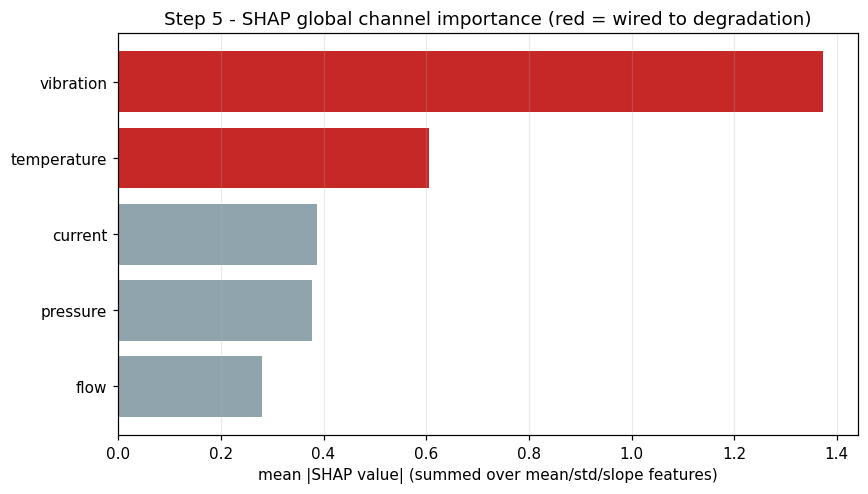

wired channels ['temperature', 'vibration'] == SHAP top-2 ['temperature', 'vibration'] : True


In [17]:
fig, ax = plt.subplots(figsize=(8, 4.6))
wired_set = set(DEGRADATION_WIRING["LITHO"].keys())
bar_colors = ["#C62828" if ch in wired_set else "#90A4AE"
             for ch in shap_table["channel"]]
ax.barh(shap_table["channel"][::-1], shap_table["mean_abs_shap"][::-1],
       color=bar_colors[::-1])
ax.set_xlabel("mean |SHAP value| (summed over mean/std/slope features)")
ax.set_title("Step 5 - SHAP global channel importance (red = wired to degradation)")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG / "m8_shap_importance.png", bbox_inches="tight", dpi=150)
plt.show()

wired_channels = set(DEGRADATION_WIRING["LITHO"].keys())
top2 = set(shap_table.loc[shap_table["rank"] <= 2, "channel"])
print(f"wired channels {sorted(wired_channels)} == SHAP top-2 {sorted(top2)} : "
      f"{wired_channels == top2}")


**Driver-recovery point.** The two channels the SHAP ranking places
at the top are exactly the two channels this project wired to the
degradation ramp (`vibration`, `temperature`); the three pure-noise
distractors sit at the bottom. This is the whole exercise: proving the
model recovers a rule that was written down in advance, which is a
detection-quality check against known ground truth, not a demonstration of
real-fab predictive power.


## Summary

| Step | Output |
|---|---|
| 1 E10 state layer | stylized per-tool timeline (PRODUCTIVE/STANDBY/SCHEDULED DOWNTIME/UNSCHEDULED DOWNTIME); ENGINEERING declared but unused; partition exact per `equipment_check.py` GATE 1 |
| 2 RAM metrics | MTBF/MTTR/availability/utilization per tool and station; NaN MTBF/MTTR where no unscheduled event occurred |
| 3 Maintenance timing | CRN-paired baseline/immediate/mid/late PM comparison; baseline-vs-baseline exact zero; immediate PM cheapest, late PM costliest in this reference demonstration |
| 4 Alert priority | LITHO priority about 1.9x METRO's on the same severity; realized CRN-paired cost impact confirms the same ranking, at a much larger ratio |
| 5 Sensor + health model | two wired channels (vibration, temperature) among five; GB held-out AUC comfortably above chance; GB cuts false-alarm rate versus single-channel EWMA at the cost of slightly slower mean detection; SHAP recovers both wired channels as the top 2 |

**What M8 adds to the decision workflow.** Before this module, a
degradation alert (M5) was a signal with no attached decision. M8 turns
that signal into a maintenance DECISION: a costed comparison of when to
act (Step 3), a transparent priority score that ranks which alert to act
on first (Step 4, validated against realized simulated cost impact, not
merely asserted), and a detection-quality comparison (Step 5) that shows
where a richer multivariate model earns its keep (false-alarm rate) versus
where a classic single-channel method stays competitive (detection speed).

**Limits.** The E10 state mapping is stylized, not standards-compliant;
`ENGINEERING` is never populated. PM downtime rate, scrap cost per
defective wafer, and processing/holding rates are illustrative constants
for internal ranking, not real fab prices. The "PM resets degradation"
semantics in Step 3 is an idealization; a real PM's effectiveness at
reversing wear is itself uncertain and often partial. The sensor channels
in Step 5 are entirely self-generated with a documented wiring rule, so
every AUC, delay, false-alarm rate, and SHAP ranking measures whether the
model recovered that rule, never real predictive maintenance capability on
an actual fab.

**Check scripts.** `py src/equipment/equipment_check.py`,
`py src/equipment/maintenance_check.py`, `py src/equipment/pdm_check.py`
all pass at the time this notebook was executed (alongside the earlier
`validate_m2.py`, `crn_check.py`, `monitoring_check.py`, `quality_check.py`,
`vm_check.py` gates this project maintains).

**Figures (`reports/figures/`):** `m8_e10_state_decomposition.png`,
`m8_pm_timing_cost.png`, `m8_alert_priority_validation.png`,
`m8_sensor_episode.png`, `m8_shap_importance.png`.


In [18]:
nb_elapsed = time.time() - NB_START
print(f"Notebook 08 total wall time: {nb_elapsed:.1f}s")


Notebook 08 total wall time: 19.1s
